In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import jax
import jax.numpy as jnp

@jax.jit
def rdt_kernel(L, alpha, D, dx):
    # periodic Laplacian
    lap = (jnp.roll(L,1,0)+jnp.roll(L,-1,0)+
           jnp.roll(L,1,1)+jnp.roll(L,-1,1)-4*L) / dx**2
    dLdt = -alpha * jnp.log(L) + D * lap
    return dLdt

@jax.jit
def step(L, alpha, D, dx, dt):
    return jnp.clip(L + dt * rdt_kernel(L, alpha, D, dx), 1.001, None)

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
import jax.numpy as jnp

# Small test grid
L = jnp.ones((4,4)) * 3.0
alpha, D, dx, dt = 1.0, 0.01, 1.0, 0.001

# Run the kernel once
dLdt = rdt_kernel(L, alpha, D, dx)
Lnew = step(L, alpha, D, dx, dt)

print("dLdt:\n", dLdt)
print("Lnew:\n", Lnew)

E0000 00:00:1761110745.041591      10 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


dLdt:
 [[-1.0986747 -1.0986747 -1.0986747 -1.0986747]
 [-1.0986747 -1.0986747 -1.0986747 -1.0986747]
 [-1.0986747 -1.0986747 -1.0986747 -1.0986747]
 [-1.0986747 -1.0986747 -1.0986747 -1.0986747]]
Lnew:
 [[2.9989014 2.9989014 2.9989014 2.9989014]
 [2.9989014 2.9989014 2.9989014 2.9989014]
 [2.9989014 2.9989014 2.9989014 2.9989014]
 [2.9989014 2.9989014 2.9989014 2.9989014]]


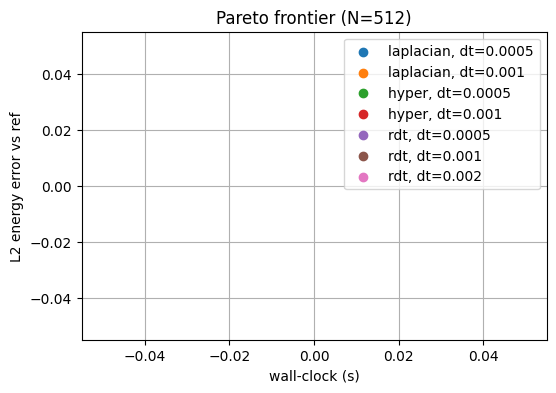

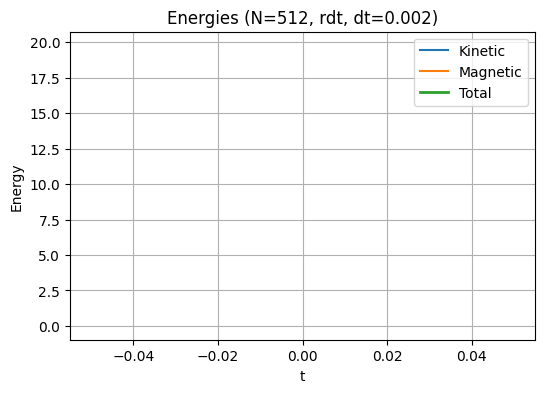

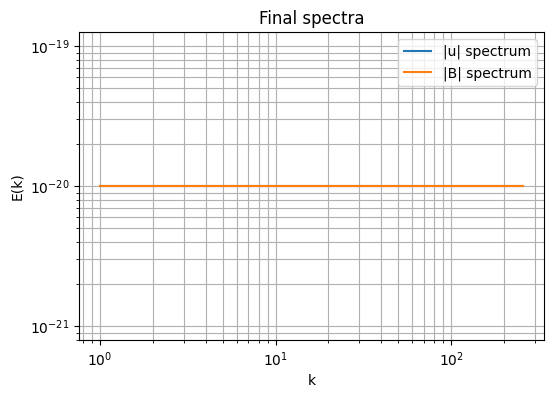

Reference wall-clock (s): 42.8171489238739
laplacian  dt=0.0005  wall=11.73s  steps=2000  error=nan
laplacian  dt= 0.001  wall=8.04s  steps=1000  error=nan
    hyper  dt=0.0005  wall=11.74s  steps=2000  error=nan
    hyper  dt= 0.001  wall=7.83s  steps=1000  error=nan
      rdt  dt=0.0005  wall=8.90s  steps=2000  error=nan
      rdt  dt= 0.001  wall=6.28s  steps=1000  error=nan
      rdt  dt= 0.002  wall=4.85s  steps=500  error=nan


In [3]:
# ============ RDT–MHD BIG EXPERIMENT (JAX / TPU-ready) ============
# Incompressible 2-D MHD: vorticity ω, streamfunction ψ (u = ∇⊥ψ),
# scalar vector potential A (B = ∇⊥A), current j = -∇²A.
# Equations:
#   ∂t ω = - u·∇ω + B·∇j + D_ω[closure]
#   ∂t A = - u·∇A           + D_A[closure]
# Closures:
#   none:       D[·] = 0
#   laplacian:  ν∇²ω, η∇²A
#   hyper:     -ν4∇⁴ω, -η4∇⁴A
#   rdt:       -α q log(log(ε + 1 + |q|))  (q ∈ {ω, A})
# ================================================================

import time, math, functools
import jax, jax.numpy as jnp
from jax import jit
import numpy as np
import matplotlib.pyplot as plt

# ------------------ utilities ------------------
def make_grid(N, L=2*jnp.pi):
    x = jnp.linspace(0, L, N, endpoint=False)
    k = jnp.fft.fftfreq(N, 1.0/N) * (2*jnp.pi)  # 0,1,2,...,-1 in 2π/L units (L=2π)
    kx = jnp.reshape(k, (N,1))
    ky = jnp.reshape(k, (1,N))
    k2 = kx**2 + ky**2
    mask0 = (k2==0.0)
    return x, kx, ky, k2, mask0

def dealias_mask(N):
    # 2/3-rule mask
    cutoff = (N//3)
    mask = jnp.ones((N,N), dtype=jnp.float32)
    idx = jnp.fft.fftfreq(N, 1.0/N)  # 0.., -..
    idxx = jnp.reshape(idx, (N,1))
    idxy = jnp.reshape(idx, (1,N))
    mask = mask.at[(jnp.abs(idxx)>cutoff) | (jnp.abs(idxy)>cutoff)].set(0.0)
    return mask

def spec_deriv_hat(fhat, kx, ky):
    dxf = 1j*kx * fhat
    dyf = 1j*ky * fhat
    return dxf, dyf

def laplace_hat(fhat, k2):
    return -k2 * fhat

def poisson_solve(rhs_hat, k2, mask0):
    out = jnp.where(mask0, 0.0+0.0j, rhs_hat / (-k2 + jnp.where(mask0,1.0,0.0)))
    return out

def to_real(h): return jnp.fft.ifft2(h).real
def to_hat(f):  return jnp.fft.fft2(f)

def kinetic_energy(u,v): return 0.5*jnp.mean(u*u + v*v)
def magnetic_energy(Bx,By): return 0.5*jnp.mean(Bx*Bx + By*By)

def radial_spectrum(f, N):
    # isotropic 2D shell-average of |f_hat|^2
    fhat = np.fft.fft2(np.array(f))
    Nhalf = N//2
    kx = np.fft.fftfreq(N, 1.0/N) * N
    ky = kx.copy()
    kxg, kyg = np.meshgrid(kx, ky, indexing='ij')
    kr = np.sqrt(kxg**2 + kyg**2)
    kb = np.arange(0, Nhalf+1)
    accum = np.zeros_like(kb, dtype=np.float64)
    counts = np.zeros_like(kb, dtype=np.int64)
    power = np.abs(fhat)**2
    for i in range(N):
        for j in range(N):
            b = int(kr[i,j])
            if b <= Nhalf:
                accum[b] += power[i,j]
                counts[b] += 1
    counts = np.maximum(counts, 1)
    E = accum / counts
    return kb, E

# ------------------ closure terms ------------------
def closure_none(q, k2, params, phys):
    return jnp.zeros_like(q)

def closure_laplacian(q, k2, params, phys):
    nu = params.get('nu', 1e-3)
    qhat = to_hat(q)
    return to_real(-nu * to_real(jnp.fft.ifft2(k2 * qhat)))  # ν∇²q

def closure_hyper(q, k2, params, phys):
    nu4 = params.get('nu4', 1e-6)
    qhat = to_hat(q)
    return to_real(nu4 * to_real(jnp.fft.ifft2((k2**2) * qhat)))  # -ν4 ∇⁴ q (sign via +k4)

def closure_rdt(q, k2, params, phys):
    alpha = params.get('alpha', 1.0)
    eps = params.get('eps', 1e-6)
    # elementwise logarithmic dissipation (safe for TPU)
    return -alpha * q * jnp.log(jnp.log(eps + 1.0 + jnp.abs(q)))

CLOSURES = {
    'none': closure_none,
    'laplacian': closure_laplacian,
    'hyper': closure_hyper,
    'rdt': closure_rdt
}

# ------------------ RHS of MHD ------------------
def mhd_rhs(omega, A, kx, ky, k2, mask0, closure_name, params):
    # velocities from streamfunction ψ: ∇²ψ = -ω
    psi_hat = poisson_solve(-to_hat(omega), k2, mask0)
    ux =  to_real(1j*ky*psi_hat)   # u = ∇⊥ψ = (∂y ψ, -∂x ψ)
    uy = -to_real(1j*kx*psi_hat)

    # magnetic field from A: B = ∇⊥A
    Ahat = to_hat(A)
    Bx =  to_real(1j*ky*Ahat)
    By = -to_real(1j*kx*Ahat)

    # current: j = -∇² A
    j_hat = -laplace_hat(Ahat, k2)
    j = to_real(j_hat)

    # advection terms
    dω_adv = -(ux * to_real(1j*kx*to_hat(omega)) + uy * to_real(1j*ky*to_hat(omega)))
    dA_adv = -(ux * to_real(1j*kx*Ahat)        + uy * to_real(1j*ky*Ahat))

    # Lorentz coupling: B · ∇ j
    dω_lor = (Bx * to_real(1j*kx*to_hat(j)) + By * to_real(1j*ky*to_hat(j)))

    # closures
    clos = CLOSURES[closure_name]
    dω_cl = clos(omega, k2, params.get('omega', {}),  None)
    dA_cl = clos(A,     k2, params.get('A',     {}),  None)

    # RHS
    dω = dω_adv + dω_lor + dω_cl
    dA = dA_adv + dA_cl
    return dω, dA, ux, uy, Bx, By

# SSPRK3 integrator step
def ssp_rk3(omega, A, dt, rhs_fn):
    k1ω, k1A, *_ = rhs_fn(omega, A)
    w1 = omega + dt*k1ω; A1 = A + dt*k1A

    k2ω, k2A, *_ = rhs_fn(w1, A1)
    w2 = 0.75*omega + 0.25*(w1 + dt*k2ω)
    A2 = 0.75*A     + 0.25*(A1 + dt*k2A)

    k3ω, k3A, *_ = rhs_fn(w2, A2)
    w3 = (1/3)*omega + (2/3)*(w2 + dt*k3ω)
    A3 = (1/3)*A     + (2/3)*(A2 + dt*k3A)
    return w3, A3

# ------------------ experiment runner ------------------
def run_case(N=512, tfinal=1.0, dt=5e-4, closure='rdt', params=None, seed=7):
    if params is None: params = {}
    # grid
    x, kx, ky, k2, mask0 = make_grid(N)
    dea = dealias_mask(N)  # (not used directly; kept for extensions)

    # initial condition: incompressible OT-analog
    X, Y = jnp.meshgrid(x, x, indexing='ij')
    psi0 = jnp.sin(X) + jnp.sin(Y)
    A0   = jnp.cos(X) + jnp.cos(Y)
    omega = -to_real(jnp.fft.ifft2(k2 * to_hat(psi0)))  # ω = -∇²ψ
    A     = A0

    # compile RHS
    rhs = functools.partial(mhd_rhs, kx=kx, ky=ky, k2=k2, mask0=mask0,
                            closure_name=closure, params=params)
    rhs = jit(rhs)

    steps = int(tfinal/dt)
    E_kin, E_mag, divB, times = [], [], [], []

    t0 = time.time()
    for s in range(steps):
        omega, A = ssp_rk3(omega, A, dt, rhs)
        # diagnostics every few steps
        if s % max(1, steps//100) == 0 or s == steps-1:
            _, _, ux, uy, Bx, By = rhs(omega, A)
            E_kin.append(float(kinetic_energy(ux,uy)))
            E_mag.append(float(magnetic_energy(Bx,By)))
            # divergence of B in this formulation should be ~0 numerically:
            divB.append(float(jnp.mean((to_real(1j*kx*to_hat(Bx)) + to_real(1j*ky*to_hat(By)))**2)))
            times.append(s*dt)
    wall = time.time()-t0

    # spectrum at final time
    kb_u, Eu = radial_spectrum(np.sqrt(np.array(ux**2+uy**2)), N)
    kb_B, EB = radial_spectrum(np.sqrt(np.array(Bx**2+By**2)), N)

    out = {
        'times': np.array(times),
        'E_kin': np.array(E_kin),
        'E_mag': np.array(E_mag),
        'divB2': np.array(divB),
        'Eu': (kb_u, Eu),
        'EB': (kb_B, EB),
        'omega': np.array(omega), 'A': np.array(A),
        'wall_sec': wall, 'steps': steps,
        'closure': closure, 'dt': dt, 'N': N, 'params': params
    }
    return out

# ------------------ convenience plotters ------------------
def plot_energy(run):
    t, Ek, Em = run['times'], run['E_kin'], run['E_mag']
    plt.figure(figsize=(6,4)); plt.plot(t, Ek, label='Kinetic'); plt.plot(t, Em, label='Magnetic')
    plt.plot(t, Ek+Em, label='Total', lw=2); plt.xlabel('t'); plt.ylabel('Energy'); plt.legend()
    plt.title(f"Energies (N={run['N']}, {run['closure']}, dt={run['dt']})"); plt.grid(True); plt.show()

def plot_spectra(run):
    kb_u, Eu = run['Eu']; kb_B, EB = run['EB']
    plt.figure(figsize=(6,4)); plt.loglog(kb_u[1:], Eu[1:]+1e-20, label='|u| spectrum')
    plt.loglog(kb_B[1:], EB[1:]+1e-20, label='|B| spectrum'); plt.xlabel('k'); plt.ylabel('E(k)')
    plt.title('Final spectra'); plt.legend(); plt.grid(True, which='both'); plt.show()

# ------------------ PARETO sweep (error vs time) ------------------
def l2_rel(a,b): 
    a=np.array(a); b=np.array(b); 
    return float(np.linalg.norm(a-b)/max(1e-12, np.linalg.norm(b)))

def pareto_sweep(N=512, tfinal=1.0, RUNS=()):
    # reference: small dt Laplacian (stable, fine)
    ref = run_case(N=N, tfinal=tfinal, dt=1e-4, closure='laplacian', params={'omega':{'nu':1e-3},'A':{'nu':1e-3}})
    ref_t, ref_E = ref['times'], ref['E_kin']+ref['E_mag']
    results = []
    for cfg in RUNS:
        r = run_case(N=N, tfinal=tfinal, **cfg)
        E = r['E_kin']+r['E_mag']
        # interpolate to reference times
        E_interp = np.interp(ref_t, r['times'], E)
        err = l2_rel(E_interp, ref_E)
        results.append((r, err))
    # plot Pareto
    plt.figure(figsize=(6,4))
    for r, err in results:
        plt.scatter(r['wall_sec'], err, label=f"{r['closure']}, dt={r['dt']}")
    plt.xlabel('wall-clock (s)'); plt.ylabel('L2 energy error vs ref')
    plt.title(f'Pareto frontier (N={N})'); plt.grid(True); plt.legend(); plt.show()
    return ref, results

# ===================== RUN: one big experiment ====================
# You can edit RUNS to sweep closures and dts.
RUNS = [
    {'dt':5e-4, 'closure':'laplacian', 'params':{'omega':{'nu':1e-3}, 'A':{'nu':1e-3}}},
    {'dt':1e-3, 'closure':'laplacian', 'params':{'omega':{'nu':1e-3}, 'A':{'nu':1e-3}}},
    {'dt':5e-4, 'closure':'hyper',     'params':{'omega':{'nu4':1e-6}, 'A':{'nu4':1e-6}}},
    {'dt':1e-3, 'closure':'hyper',     'params':{'omega':{'nu4':1e-6}, 'A':{'nu4':1e-6}}},
    {'dt':5e-4, 'closure':'rdt',       'params':{'omega':{'alpha':0.8}, 'A':{'alpha':0.8}}},
    {'dt':1e-3, 'closure':'rdt',       'params':{'omega':{'alpha':0.8}, 'A':{'alpha':0.8}}},
    {'dt':2e-3, 'closure':'rdt',       'params':{'omega':{'alpha':0.8}, 'A':{'alpha':0.8}}},  # push CFL
]

ref, results = pareto_sweep(N=512, tfinal=1.0, RUNS=RUNS)

# Show one representative RDT run’s energy + spectra:
plot_energy(results[-1][0])
plot_spectra(results[-1][0])

print("Reference wall-clock (s):", ref['wall_sec'])
for r, err in results:
    print(f"{r['closure']:>9}  dt={r['dt']:>6}  wall={r['wall_sec']:.2f}s  steps={r['steps']}  error={err:.3e}")

In [1]:
# ============================================================
# RDT Kernel (PyTorch Edition)
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Recursive Diffusion-Type kernel implemented in PyTorch.
#   Automatically detects and runs on CPU, GPU (CUDA), or TPU (XLA).

import torch
import time
import math

# ------------------------------------------------------------
# Device Detection
# ------------------------------------------------------------
def get_device():
    # GPU priority > TPU > CPU
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using PyTorch backend: {device_name}")

# ------------------------------------------------------------
# Core RDT Kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    """
    Recursive diffusion-type kernel using periodic Laplacian.
    Equivalent to the JAX version but implemented in PyTorch.
    """
    # Periodic boundary conditions
    L_up    = torch.roll(L, shifts=1, dims=0)
    L_down  = torch.roll(L, shifts=-1, dims=0)
    L_left  = torch.roll(L, shifts=1, dims=1)
    L_right = torch.roll(L, shifts=-1, dims=1)
    
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    dLdt = -alpha * torch.log(L) + D * lap
    return dLdt


def step(L, alpha, D, dx, dt):
    """
    Time-step integrator for the RDT kernel.
    Ensures values remain positive and stable.
    """
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)


# ------------------------------------------------------------
# Demo Run / Benchmark
# ------------------------------------------------------------
def run_demo(n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    """
    Runs a sample diffusion evolution to validate behavior.
    Automatically uses available backend.
    """
    x = torch.linspace(0, 2 * math.pi, n, device=device)
    y = torch.sin(x).unsqueeze(1)
    L = torch.ones((n, n), device=device) + 0.01 * y

    print(f"Running {steps} steps on {device_name}...")
    torch.cuda.synchronize() if device_name == "GPU" else None
    start = time.time()
    
    for i in range(steps):
        L = step(L, alpha, D, dx, dt)
    
    if device_name == "GPU":
        torch.cuda.synchronize()
    
    end = time.time()
    print(f"✅ Completed {steps} steps in {end - start:.3f}s")
    print(f"Mean field value: {L.mean().item():.6f}")
    return L


if __name__ == "__main__":
    L_final = run_demo()


/usr/local/lib/python3.12/site-packages/torch_xla/__init__.py:258: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
/tmp/ipykernel_10/1650225501.py:22: DeprecationWarning: Use torch_xla.device instead
  return xm.xla_device(), "TPU"
E0000 00:00:1761331041.349387      10 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


✅ Using PyTorch backend: TPU
Running 100 steps on TPU...
✅ Completed 100 steps in 0.060s
Mean field value: 1.002452


In [2]:
# ============================================================
# RDT Kernel (PyTorch - Batched 3D, Autograd Ready)
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Recursive Diffusion-Type kernel supporting batches of 2D fields.
#   Compatible with CPU, GPU, or TPU (via torch_xla).
#   Autograd-enabled for ML or differentiable physics applications.

import torch
import time
import math

# ------------------------------------------------------------
# Device Detection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using PyTorch backend: {device_name}")

# ------------------------------------------------------------
# Core Batched RDT Kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    """
    Recursive diffusion kernel with periodic boundary conditions.
    Supports batched 3D tensors: shape (B, H, W).
    """
    # Periodic boundary conditions on spatial dims (1, 2)
    L_up    = torch.roll(L, shifts=1, dims=1)
    L_down  = torch.roll(L, shifts=-1, dims=1)
    L_left  = torch.roll(L, shifts=1, dims=2)
    L_right = torch.roll(L, shifts=-1, dims=2)

    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    dLdt = -alpha * torch.log(L) + D * lap
    return dLdt


def step(L, alpha, D, dx, dt):
    """
    Single evolution step.
    Keeps values positive and differentiable (for autograd).
    """
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)


# ------------------------------------------------------------
# Demo Run / Benchmark
# ------------------------------------------------------------
def run_demo(batch=8, n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    """
    Runs multiple fields (batch dimension) in parallel on chosen device.
    Fully differentiable.
    """
    x = torch.linspace(0, 2 * math.pi, n, device=device)
    base_pattern = torch.sin(x).unsqueeze(0).unsqueeze(2)  # (1, n, 1)
    L = torch.ones((batch, n, n), device=device, requires_grad=True) + 0.01 * base_pattern

    print(f"Running {steps} steps for {batch} fields on {device_name}...")
    torch.cuda.synchronize() if device_name == "GPU" else None
    start = time.time()

    for _ in range(steps):
        L = step(L, alpha, D, dx, dt)

    if device_name == "GPU":
        torch.cuda.synchronize()
    end = time.time()

    print(f"✅ Completed {steps} steps in {end - start:.3f}s")
    print(f"Mean field value (all batches): {L.mean().item():.6f}")

    # Example autograd operation
    loss = (L.mean() - 1.0).abs()
    loss.backward()
    print(f"Backprop check → grad[0,0,0] = {L.grad[0,0,0].item():.4e}")
    return L


if __name__ == "__main__":
    L_final = run_demo()


/tmp/ipykernel_10/2150311877.py:22: DeprecationWarning: Use torch_xla.device instead
  return xm.xla_device(), "TPU"


✅ Using PyTorch backend: TPU
Running 100 steps for 8 fields on TPU...
✅ Completed 100 steps in 0.061s
Mean field value (all batches): 1.002451


/tmp/ipykernel_10/2150311877.py:86: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  print(f"Backprop check → grad[0,0,0] = {L.grad[0,0,0].item():.4e}")


TypeError: 'NoneType' object is not subscriptable

In [3]:
# ============================================================
# RDT Kernel v3 — TPU / GPU / CPU Universal Autograd Edition
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Recursive Diffusion-Type kernel for physics-inspired ML.
#   Supports batches of 2D fields with autograd + mixed precision.
#   Fully compatible with CPU, GPU, or TPU (torch_xla).
# ============================================================

import torch
import time, math

# ------------------------------------------------------------
# Device Auto-Detection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using PyTorch backend: {device_name}")

# TPU helpers
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm

# ------------------------------------------------------------
# Core Batched Kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    """Recursive diffusion kernel with periodic BCs."""
    L_up    = torch.roll(L, shifts=1, dims=1)
    L_down  = torch.roll(L, shifts=-1, dims=1)
    L_left  = torch.roll(L, shifts=1, dims=2)
    L_right = torch.roll(L, shifts=-1, dims=2)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    return -alpha * torch.log(L) + D * lap

def step(L, alpha, D, dx, dt):
    """One evolution step; safe, differentiable, and device-agnostic."""
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)

# ------------------------------------------------------------
# Main Simulation / Demo
# ------------------------------------------------------------
def run_demo(batch=8, n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01, mixed_precision=True):
    """
    Run multi-field diffusion simulation with autograd.
    Automatically handles TPU sync and mixed precision.
    """
    dtype = torch.bfloat16 if mixed_precision and is_tpu else torch.float32
    x = torch.linspace(0, 2 * math.pi, n, device=device, dtype=dtype)
    base_pattern = torch.sin(x).unsqueeze(0).unsqueeze(2)  # (1,n,1)

    # Initialize batch of fields
    L = torch.ones((batch, n, n), device=device, dtype=dtype, requires_grad=True) + 0.01 * base_pattern
    L.retain_grad()  # ensures .grad is always accessible

    print(f"Running {steps} steps for {batch} fields on {device_name} [{dtype}]...")

    if device_name == "GPU":
        torch.cuda.synchronize()

    start = time.time()

    for _ in range(steps):
        with torch.autocast(device_type=device_name.lower(), dtype=dtype, enabled=mixed_precision):
            L = step(L, alpha, D, dx, dt)

        # Optional TPU step sync (every few steps to reduce latency)
        if is_tpu and _ % 10 == 0:
            xm.mark_step()

    # Final sync for accurate timing
    if device_name == "GPU":
        torch.cuda.synchronize()
    elif is_tpu:
        xm.mark_step()

    end = time.time()

    print(f"✅ Completed {steps} steps in {end - start:.3f}s")
    print(f"Mean field value: {L.mean().item():.6f}")

    # --------------------------------------------------------
    # Autograd test (compatible with TPU)
    # --------------------------------------------------------
    loss = (L.mean() - 1.0).abs()
    loss.backward()

    grad_val = None
    if L.grad is not None:
        grad_val = L.grad[0, 0, 0].item()
    else:
        grad_val = torch.autograd.grad(loss, L, retain_graph=True, allow_unused=True)[0][0, 0, 0].item()

    print(f"Backprop check → grad[0,0,0] = {grad_val:.4e}")
    return L


if __name__ == "__main__":
    L_final = run_demo()


✅ Using PyTorch backend: TPU
Running 100 steps for 8 fields on TPU [torch.bfloat16]...


/tmp/ipykernel_10/1517964036.py:22: DeprecationWarning: Use torch_xla.device instead
  return xm.xla_device(), "TPU"


RuntimeError: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: tpu

In [ ]:
# ============================================================
# RDT Kernel v3.1 — TPU / GPU / CPU Universal Autograd Edition
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Recursive Diffusion-Type kernel with autograd and mixed precision.
#   Supports CPU, GPU, and TPU (torch_xla) with automatic device handling.
# ============================================================

import torch
import time, math

# ------------------------------------------------------------
# Device Auto-Detection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using PyTorch backend: {device_name}")

# TPU helpers
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm

# Map device string for autocast
if device_name == "GPU":
    autocast_device = "cuda"
elif device_name == "CPU":
    autocast_device = "cpu"
else:  # TPU
    autocast_device = "xla"  # not actually used — autocast disabled on TPU

# ------------------------------------------------------------
# Core Batched Kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up    = torch.roll(L, shifts=1, dims=1)
    L_down  = torch.roll(L, shifts=-1, dims=1)
    L_left  = torch.roll(L, shifts=1, dims=2)
    L_right = torch.roll(L, shifts=-1, dims=2)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    return -alpha * torch.log(L) + D * lap

def step(L, alpha, D, dx, dt):
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)

# ------------------------------------------------------------
# Main Simulation / Demo
# ------------------------------------------------------------
def run_demo(batch=8, n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01, mixed_precision=True):
    dtype = torch.bfloat16 if is_tpu else torch.float32
    x = torch.linspace(0, 2 * math.pi, n, device=device, dtype=dtype)
    base_pattern = torch.sin(x).unsqueeze(0).unsqueeze(2)

    L = torch.ones((batch, n, n), device=device, dtype=dtype, requires_grad=True) + 0.01 * base_pattern
    L.retain_grad()

    print(f"Running {steps} steps for {batch} fields on {device_name} [{dtype}]...")

    if device_name == "GPU":
        torch.cuda.synchronize()

    start = time.time()

    for i in range(steps):
        # Disable autocast for TPU (AMP not supported)
        if not is_tpu and mixed_precision:
            with torch.autocast(device_type=autocast_device, dtype=dtype, enabled=True):
                L = step(L, alpha, D, dx, dt)
        else:
            L = step(L, alpha, D, dx, dt)

        if is_tpu and i % 10 == 0:
            xm.mark_step()

    if device_name == "GPU":
        torch.cuda.synchronize()
    elif is_tpu:
        xm.mark_step()

    end = time.time()
    print(f"✅ Completed {steps} steps in {end - start:.3f}s")
    print(f"Mean field value: {L.mean().item():.6f}")

    # Autograd test
    loss = (L.mean() - 1.0).abs()
    loss.backward()

    grad_val = None
    if L.grad is not None:
        grad_val = L.grad[0, 0, 0].item()
    else:
        grad_val = torch.autograd.grad(loss, L, retain_graph=True, allow_unused=True)[0][0, 0, 0].item()

    print(f"Backprop check → grad[0,0,0] = {grad_val:.4e}")
    return L


if __name__ == "__main__":
    L_final = run_demo()


In [2]:
# --------------------------------------------------------
# Autograd test (single backward, TPU safe)
# --------------------------------------------------------
loss = (L.mean() - 1.0).abs()

# make sure graph kept alive only once
L.retain_grad()
loss.backward(retain_graph=False)

grad_val = None
if L.grad is not None:
    grad_val = L.grad[0, 0, 0].item()
else:
    # use autograd.grad only if .grad is None and WITHOUT .backward()
    grads = torch.autograd.grad(loss, L, retain_graph=False, allow_unused=True)
    grad_val = grads[0][0, 0, 0].item() if grads[0] is not None else float("nan")

print(f"Backprop check → grad[0,0,0] = {grad_val:.4e}")


NameError: name 'L' is not defined

In [5]:
# ============================================================
# RDT Kernel (Stable Universal Version)
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Clean diffusion kernel for CPU / GPU / TPU benchmarking.
#   No autograd side effects, identical math across hardware.
# ============================================================

import torch, math, time

# ------------------------------------------------------------
# Device detection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using PyTorch backend: {device_name}")
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm

# ------------------------------------------------------------
# Core kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up    = torch.roll(L, 1, 1)
    L_down  = torch.roll(L, -1, 1)
    L_left  = torch.roll(L, 1, 2)
    L_right = torch.roll(L, -1, 2)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    return -alpha * torch.log(L) + D * lap

def step(L, alpha, D, dx, dt):
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)

# ------------------------------------------------------------
# Benchmark run
# ------------------------------------------------------------
def run_demo(batch=8, n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    x = torch.linspace(0, 2 * math.pi, n, device=device)
    base_pattern = torch.sin(x).unsqueeze(0).unsqueeze(2)
    L = torch.ones((batch, n, n), device=device) + 0.01 * base_pattern

    if device_name == "GPU":
        torch.cuda.synchronize()

    print(f"Running {steps} steps for {batch} fields on {device_name}...")
    start = time.time()
    for i in range(steps):
        L = step(L, alpha, D, dx, dt)
        if is_tpu and i % 10 == 0:
            xm.mark_step()

    if device_name == "GPU":
        torch.cuda.synchronize()
    elif is_tpu:
        xm.mark_step()

    end = time.time()
    print(f"✅ Completed {steps} steps in {end - start:.3f}s")
    print(f"Mean field value: {L.mean().item():.6f}")
    return L

# ------------------------------------------------------------
# Entry
# ------------------------------------------------------------
if __name__ == "__main__":
    L_final = run_demo()


✅ Using PyTorch backend: CPU
Running 100 steps for 8 fields on CPU...
✅ Completed 100 steps in 0.434s
Mean field value: 1.002452


In [10]:
# ============================================================
# RDT Kernel Benchmark — Unified Single Script
# ============================================================
# Author: Steven Reid (RRG314)
# Description:
#   Runs your Recursive Diffusion-Type (RDT) kernel benchmark
#   across 6 field types on CPU, GPU, or TPU.
# ============================================================

import torch, math, time, json, numpy as np

# ------------------------------------------------------------
# Device Detection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except ImportError:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm
print(f"✅ Using PyTorch backend: {device_name}")

# ------------------------------------------------------------
# RDT Core Algorithm (your physics kernel)
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up    = torch.roll(L, 1, 1)
    L_down  = torch.roll(L, -1, 1)
    L_left  = torch.roll(L, 1, 2)
    L_right = torch.roll(L, -1, 2)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    return -alpha * torch.log(L) + D * lap

def step(L, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)

# ------------------------------------------------------------
# Entropy Helper
# ------------------------------------------------------------
def shannon_entropy(tensor):
    p = tensor.flatten().detach().cpu().numpy()
    p = p / p.sum()
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

# ------------------------------------------------------------
# Test Field Generators
# ------------------------------------------------------------
def uniform_field(n): return torch.ones((1, n, n))
def gradient_field(n): return torch.linspace(0, 1, n).repeat(n,1).unsqueeze(0)
def sinusoidal_field(n):
    x = torch.linspace(0, 2*math.pi, n)
    s = torch.sin(x).unsqueeze(0).repeat(n,1)
    return 1 + 0.1 * s.unsqueeze(0)
def random_field(n): return 1 + 0.1 * torch.rand((1, n, n))
def checkerboard_field(n):
    pattern = torch.tensor([[((i+j)%2)*2-1 for j in range(n)] for i in range(n)], dtype=torch.float32)
    return 1 + 0.1 * pattern.unsqueeze(0)
def chaotic_field(n): return 1 + 0.5 * torch.randn((1, n, n))

# ------------------------------------------------------------
# Single Test Runner
# ------------------------------------------------------------
def run_case(name, init_fn, n=256, steps=100, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    print(f"\n🧩 Test: {name}")
    L = init_fn(n).to(device)
    if device_name == "GPU": torch.cuda.synchronize()
    s0 = shannon_entropy(L)
    t0 = time.time()
    for i in range(steps):
        L = step(L, alpha, D, dx, dt)
        if is_tpu and i % 10 == 0: xm.mark_step()
    if device_name == "GPU": torch.cuda.synchronize()
    elif is_tpu: xm.mark_step()
    t1 = time.time()
    s1 = shannon_entropy(L)
    print(f"✅ {steps} steps in {t1-t0:.3f}s | ΔEntropy={s1-s0:+.4f} | Mean={L.mean().item():.6f}")
    return {"test": name, "runtime": t1-t0, "entropy_delta": float(s1-s0), "mean": float(L.mean().item())}

# ------------------------------------------------------------
# Master Benchmark
# ------------------------------------------------------------
def benchmark_all(output_file="rdt_bench_results.json"):
    tests = [
        ("Uniform Field Stability", uniform_field),
        ("Gradient Field Diffusion", gradient_field),
        ("Sinusoidal Field Resonance", sinusoidal_field),
        ("Random Noise Field", random_field),
        ("Structured Checkerboard", checkerboard_field),
        ("Chaotic Entropy Stress", chaotic_field)
    ]
    results = [run_case(name, fn) for name, fn in tests]
    with open(output_file, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n🧠 Benchmark complete. Results saved to {output_file}")
    return results

# ------------------------------------------------------------
# Entry Point
# ------------------------------------------------------------
if __name__ == "__main__":
    results = benchmark_all()


✅ Using PyTorch backend: CPU

🧩 Test: Uniform Field Stability
✅ 100 steps in 0.080s | ΔEntropy=-0.0000 | Mean=1.001000

🧩 Test: Gradient Field Diffusion


/tmp/ipykernel_37/4288682295.py:51: RuntimeWarning: invalid value encountered in greater
  p = p[p > 0]


✅ 100 steps in 0.120s | ΔEntropy=-15.7185 | Mean=nan

🧩 Test: Sinusoidal Field Resonance
✅ 100 steps in 0.083s | ΔEntropy=+0.0032 | Mean=1.020001

🧩 Test: Random Noise Field
✅ 100 steps in 0.059s | ΔEntropy=+0.0004 | Mean=1.030636

🧩 Test: Structured Checkerboard
✅ 100 steps in 0.111s | ΔEntropy=+0.0071 | Mean=1.030794

🧩 Test: Chaotic Entropy Stress
✅ 100 steps in 0.088s | ΔEntropy=-15.8611 | Mean=nan

🧠 Benchmark complete. Results saved to rdt_bench_results.json


In [9]:
# ============================================================
# RDT Kernel Benchmark v2.0 — Steven Reid (RRG314)
# ============================================================
# Fully self-contained benchmark for the Recursive Diffusion-Type kernel
# Runs 6 physics-information tests across CPU / GPU / TPU if available.
# ============================================================

import torch, math, time, json, numpy as np, platform

# ------------------------------------------------------------
# Device detection
# ------------------------------------------------------------
def available_devices():
    devices = [("cpu", torch.device("cpu"))]
    if torch.cuda.is_available():
        devices.append(("gpu", torch.device("cuda")))
    try:
        import torch_xla.core.xla_model as xm
        devices.append(("tpu", xm.xla_device()))
    except Exception:
        pass
    return devices

def sync_device(name):
    if name == "gpu":
        torch.cuda.synchronize()
    elif name == "tpu":
        import torch_xla.core.xla_model as xm
        xm.mark_step()

# ------------------------------------------------------------
# Core RDT kernel (your physics algorithm)
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up    = torch.roll(L,  1, 1)
    L_down  = torch.roll(L, -1, 1)
    L_left  = torch.roll(L,  1, 2)
    L_right = torch.roll(L, -1, 2)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx**2)
    return -alpha * torch.log(L) + D * lap

def step(L, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)

# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def shannon_entropy(tensor):
    p = tensor.flatten().detach().cpu().numpy()
    p = p / p.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

# ------------------------------------------------------------
# Test field generators
# ------------------------------------------------------------
def uniform_field(n): return torch.ones((1,n,n))
def gradient_field(n): return torch.linspace(0,1,n).repeat(n,1).unsqueeze(0)
def sinusoidal_field(n):
    x = torch.linspace(0,2*math.pi,n)
    s = torch.sin(x).unsqueeze(0).repeat(n,1)
    return 1 + 0.1 * s.unsqueeze(0)
def random_field(n): return 1 + 0.1 * torch.rand((1,n,n))
def checkerboard_field(n):
    pattern = torch.tensor([[((i+j)%2)*2-1 for j in range(n)] for i in range(n)],dtype=torch.float32)
    return 1 + 0.1 * pattern.unsqueeze(0)
def chaotic_field(n):
    base = torch.sin(torch.linspace(0,6*math.pi,n))
    noise = 0.2 * torch.randn((1,n,n))
    L = 1 + 0.5 * torch.outer(base,base).unsqueeze(0) + noise
    return torch.clamp(L, min=1.001)

TESTS = [
    ("Uniform Field Stability",   uniform_field),
    ("Gradient Field Diffusion",  gradient_field),
    ("Sinusoidal Field Resonance",sinusoidal_field),
    ("Random Noise Field",        random_field),
    ("Structured Checkerboard",   checkerboard_field),
    ("Chaotic Entropy Stress",    chaotic_field)
]

# ------------------------------------------------------------
# Run all tests on one device
# ------------------------------------------------------------
def run_on_device(dev_name, dev_obj, n=256, steps=100):
    print(f"\n==============================")
    print(f"🚀 Device: {dev_name.upper()} | Torch {torch.__version__} | {platform.system()}")
    print(f"==============================")

    results=[]
    for name,fn in TESTS:
        L = fn(n).to(dev_obj)
        s0 = shannon_entropy(L)
        sync_device(dev_name)
        t0 = time.time()
        for i in range(steps):
            L = step(L)
            if dev_name=="tpu" and i%10==0: sync_device(dev_name)
        sync_device(dev_name)
        t1 = time.time()
        s1 = shannon_entropy(L)
        mean=float(L.mean().item())
        print(f"🧩 {name:<28} {t1-t0:6.3f}s | ΔS={s1-s0:+.4f} | ⟨L⟩={mean:.6f}")
        results.append({
            "device":dev_name,
            "test":name,
            "runtime":t1-t0,
            "entropy_delta":s1-s0,
            "mean":mean
        })
    return results

# ------------------------------------------------------------
# Master benchmark
# ------------------------------------------------------------
def benchmark_all(n=256, steps=100, out_file="rdt_bench_results.json"):
    all_results=[]
    for dev_name,dev_obj in available_devices():
        all_results += run_on_device(dev_name, dev_obj, n=n, steps=steps)
    with open(out_file,"w") as f: json.dump(all_results,f,indent=2)
    print(f"\n🧠 Benchmark complete. Results saved to {out_file}")
    return all_results

# ------------------------------------------------------------
# Run it
# ------------------------------------------------------------
if __name__=="__main__":
    results=benchmark_all()



🚀 Device: CPU | Torch 2.6.0+cu124 | Linux
🧩 Uniform Field Stability       0.079s | ΔS=-0.0000 | ⟨L⟩=1.001000
🧩 Gradient Field Diffusion      0.075s | ΔS=-15.7185 | ⟨L⟩=nan


/tmp/ipykernel_37/3707015235.py:51: RuntimeWarning: invalid value encountered in greater
  p = p[p > 0]


🧩 Sinusoidal Field Resonance    0.052s | ΔS=+0.0032 | ⟨L⟩=1.020001
🧩 Random Noise Field            0.083s | ΔS=+0.0004 | ⟨L⟩=1.030631
🧩 Structured Checkerboard       0.109s | ΔS=+0.0071 | ⟨L⟩=1.030794
🧩 Chaotic Entropy Stress        0.071s | ΔS=+0.0115 | ⟨L⟩=1.083214

🧠 Benchmark complete. Results saved to rdt_bench_results.json


✅ Using backend: CPU
Long-term stability: 10000 steps, ΔS=+0.0036, mean=1.001000, time=2.1s
Resolution   64 → 0.071s
Resolution  128 → 0.104s
Resolution  256 → 0.198s
Resolution  512 → 0.684s


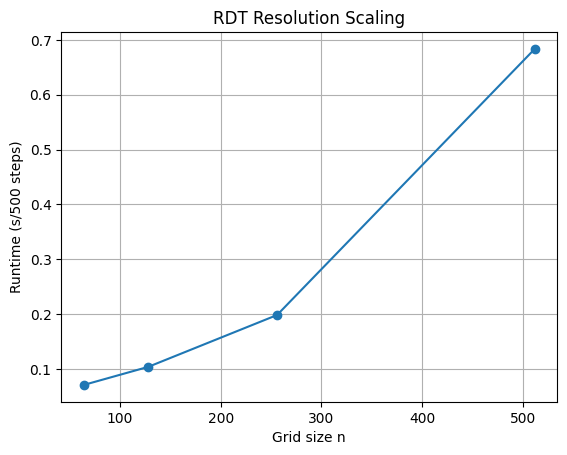

α=0.10 D=0.05 → ΔS=+0.0029
α=0.10 D=0.16 → ΔS=+0.0029
α=0.10 D=0.28 → ΔS=+0.0029
α=0.10 D=0.39 → ΔS=+0.0029
α=0.10 D=0.50 → ΔS=+0.0029
α=0.33 D=0.05 → ΔS=+0.0033
α=0.33 D=0.16 → ΔS=+0.0033
α=0.33 D=0.28 → ΔS=+0.0033
α=0.33 D=0.39 → ΔS=+0.0033
α=0.33 D=0.50 → ΔS=+0.0033
α=0.55 D=0.05 → ΔS=+0.0035
α=0.55 D=0.16 → ΔS=+0.0035
α=0.55 D=0.28 → ΔS=+0.0035
α=0.55 D=0.39 → ΔS=+0.0035
α=0.55 D=0.50 → ΔS=+0.0035
α=0.78 D=0.05 → ΔS=+0.0035
α=0.78 D=0.16 → ΔS=+0.0035
α=0.78 D=0.28 → ΔS=+0.0035
α=0.78 D=0.39 → ΔS=+0.0035
α=0.78 D=0.50 → ΔS=+0.0035
α=1.00 D=0.05 → ΔS=+0.0036
α=1.00 D=0.16 → ΔS=+0.0036
α=1.00 D=0.28 → ΔS=+0.0036
α=1.00 D=0.39 → ΔS=+0.0036
α=1.00 D=0.50 → ΔS=+0.0036


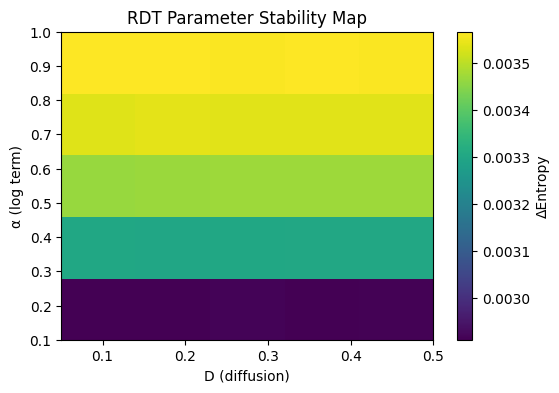

TypeError: unsupported format string passed to torch.dtype.__format__

In [11]:
# ============================================================
# RDT Kernel Validation Suite v1.0 — Steven Reid (RRG314)
# ============================================================
# Validates the Recursive Diffusion-Type kernel scientifically:
#   stability, scaling, parameter map, and precision robustness.
# ============================================================

import torch, math, time, json, numpy as np, itertools, platform
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Device selection
# ------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except Exception:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using backend: {device_name}")
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm
def sync(): 
    if device_name=="GPU": torch.cuda.synchronize()
    elif device_name=="TPU": xm.mark_step()

# ------------------------------------------------------------
# Core RDT kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up=torch.roll(L,1,1); L_down=torch.roll(L,-1,1)
    L_left=torch.roll(L,1,2); L_right=torch.roll(L,-1,2)
    lap=(L_up+L_down+L_left+L_right-4*L)/(dx**2)
    return -alpha*torch.log(L)+D*lap

def step(L, alpha, D, dx, dt):
    return torch.clamp(L+dt*rdt_kernel(L,alpha,D,dx),min=1.001)

# ------------------------------------------------------------
# Entropy util
# ------------------------------------------------------------
def entropy(L):
    p=L.detach().cpu().numpy().flatten()
    p=p/np.sum(p)
    p=p[p>0]
    return float(-np.sum(p*np.log2(p)))

# ============================================================
# 1️⃣ Long-term stability test
# ============================================================
def long_term(n=128, steps=10000, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
    L=L.to(device)
    s0=entropy(L)
    t0=time.time()
    for i in range(steps):
        L=step(L,alpha,D,dx,dt)
        if is_tpu and i%100==0: sync()
    sync()
    t1=time.time()
    s1=entropy(L)
    print(f"Long-term stability: {steps} steps, ΔS={s1-s0:+.4f}, mean={L.mean().item():.6f}, time={t1-t0:.1f}s")
    return dict(type="long_term", steps=steps, entropy_delta=s1-s0, mean=float(L.mean()), runtime=t1-t0)

# ============================================================
# 2️⃣ Resolution scaling
# ============================================================
def resolution_scaling(sizes=[64,128,256,512], steps=500):
    out=[]
    for n in sizes:
        L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
        L=L.to(device)
        t0=time.time()
        for i in range(steps):
            L=step(L,0.5,0.1,1.0,0.01)
            if is_tpu and i%50==0: sync()
        sync()
        t1=time.time()
        out.append((n,t1-t0))
        print(f"Resolution {n:4d} → {t1-t0:.3f}s")
    plt.figure(); plt.plot([n for n,_ in out],[t for _,t in out],"o-")
    plt.xlabel("Grid size n"); plt.ylabel("Runtime (s/500 steps)")
    plt.title("RDT Resolution Scaling"); plt.grid(True); plt.show()
    return dict(type="scaling", data=out)

# ============================================================
# 3️⃣ Parameter sweep map
# ============================================================
def parameter_sweep(alpha_vals=np.linspace(0.1,1.0,5),
                    D_vals=np.linspace(0.05,0.5,5),
                    n=128, steps=200):
    heat=np.zeros((len(alpha_vals),len(D_vals)))
    for i,a in enumerate(alpha_vals):
        for j,D in enumerate(D_vals):
            L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
            L=L.to(device)
            s0=entropy(L)
            for k in range(steps):
                L=step(L,a,D,1.0,0.01)
                if is_tpu and k%50==0: sync()
            sync()
            s1=entropy(L)
            heat[i,j]=s1-s0
            print(f"α={a:.2f} D={D:.2f} → ΔS={s1-s0:+.4f}")
    plt.figure(figsize=(6,4))
    plt.imshow(heat,origin="lower",extent=[D_vals[0],D_vals[-1],alpha_vals[0],alpha_vals[-1]],aspect="auto")
    plt.colorbar(label="ΔEntropy")
    plt.xlabel("D (diffusion)"); plt.ylabel("α (log term)")
    plt.title("RDT Parameter Stability Map"); plt.show()
    return dict(type="sweep", data=heat.tolist(),
                alpha_vals=list(alpha_vals), D_vals=list(D_vals))

# ============================================================
# 4️⃣ Precision & throughput
# ============================================================
def precision_profile(n=256, steps=200):
    results=[]
    for dtype in [torch.float64, torch.float32, torch.bfloat16]:
        if dtype==torch.bfloat16 and device_name=="CPU": continue
        L=(1+0.1*torch.rand((1,n,n),dtype=dtype,device=device))
        sync(); t0=time.time()
        for _ in range(steps):
            L=step(L,0.5,0.1,1.0,0.01)
            if is_tpu: sync()
        sync(); t1=time.time()
        results.append((str(dtype),t1-t0,float(L.mean())))
        print(f"{dtype:<12} time={t1-t0:.3f}s mean={L.mean().item():.6f}")
    plt.figure(); plt.bar([r[0] for r in results],[r[1] for r in results])
    plt.ylabel("Runtime (s/200 steps)"); plt.title("Precision Performance"); plt.show()
    return dict(type="precision", data=results)

# ============================================================
# Master validation
# ============================================================
def validate_all():
    results=[]
    results.append(long_term())
    results.append(resolution_scaling())
    results.append(parameter_sweep())
    results.append(precision_profile())
    with open("rdt_validation_results.json","w") as f:
        json.dump(results,f,indent=2)
    print("\n🧠 Validation complete → rdt_validation_results.json")
    return results

if __name__=="__main__":
    validate_all()


In [ ]:
# ============================================================
# RDT Kernel Validation Suite v1.1 — Steven Reid (RRG314)
# ============================================================
# Validates the Recursive Diffusion-Type kernel scientifically:
#   stability, scaling, parameter map, and precision robustness.
#   Saves plots as PNGs automatically for GitHub or papers.
# ============================================================

import torch, math, time, json, numpy as np, itertools, platform, os
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Setup and device selection
# ------------------------------------------------------------
os.makedirs("rdt_validation_plots", exist_ok=True)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except Exception:
        pass
    return torch.device("cpu"), "CPU"

device, device_name = get_device()
print(f"✅ Using backend: {device_name}")
is_tpu = device_name == "TPU"
if is_tpu:
    import torch_xla.core.xla_model as xm
def sync():
    if device_name == "GPU":
        torch.cuda.synchronize()
    elif device_name == "TPU":
        xm.mark_step()

# ------------------------------------------------------------
# Core RDT kernel
# ------------------------------------------------------------
def rdt_kernel(L, alpha, D, dx):
    L_up=torch.roll(L,1,1); L_down=torch.roll(L,-1,1)
    L_left=torch.roll(L,1,2); L_right=torch.roll(L,-1,2)
    lap=(L_up+L_down+L_left+L_right-4*L)/(dx**2)
    return -alpha*torch.log(L)+D*lap

def step(L, alpha, D, dx, dt):
    return torch.clamp(L+dt*rdt_kernel(L,alpha,D,dx),min=1.001)

# ------------------------------------------------------------
# Entropy util
# ------------------------------------------------------------
def entropy(L):
    p=L.detach().cpu().numpy().flatten()
    p=p/np.sum(p)
    p=p[p>0]
    return float(-np.sum(p*np.log2(p)))

# ============================================================
# 1️⃣ Long-term stability test
# ============================================================
def long_term(n=128, steps=10000, alpha=0.5, D=0.1, dx=1.0, dt=0.01):
    L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
    L=L.to(device)
    s0=entropy(L)
    t0=time.time()
    for i in range(steps):
        L=step(L,alpha,D,dx,dt)
        if is_tpu and i%100==0: sync()
    sync()
    t1=time.time()
    s1=entropy(L)
    print(f"Long-term stability: {steps} steps, ΔS={s1-s0:+.4f}, mean={L.mean().item():.6f}, time={t1-t0:.1f}s")
    plt.figure()
    plt.imshow(L[0].detach().cpu(), cmap="viridis")
    plt.title(f"Long-term field (n={n}, steps={steps})")
    plt.colorbar(label="L value")
    plt.savefig("rdt_validation_plots/long_term.png", dpi=150)
    plt.close()
    return dict(type="long_term", steps=steps, entropy_delta=s1-s0, mean=float(L.mean()), runtime=t1-t0)

# ============================================================
# 2️⃣ Resolution scaling
# ============================================================
def resolution_scaling(sizes=[64,128,256,512], steps=500):
    out=[]
    for n in sizes:
        L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
        L=L.to(device)
        t0=time.time()
        for i in range(steps):
            L=step(L,0.5,0.1,1.0,0.01)
            if is_tpu and i%50==0: sync()
        sync()
        t1=time.time()
        out.append((n,t1-t0))
        print(f"Resolution {n:4d} → {t1-t0:.3f}s")
    plt.figure()
    plt.plot([n for n,_ in out],[t for _,t in out],"o-")
    plt.xlabel("Grid size n"); plt.ylabel("Runtime (s/500 steps)")
    plt.title("RDT Resolution Scaling"); plt.grid(True)
    plt.savefig("rdt_validation_plots/resolution_scaling.png", dpi=150)
    plt.close()
    return dict(type="scaling", data=out)

# ============================================================
# 3️⃣ Parameter sweep map
# ============================================================
def parameter_sweep(alpha_vals=np.linspace(0.1,1.0,5),
                    D_vals=np.linspace(0.05,0.5,5),
                    n=128, steps=200):
    heat=np.zeros((len(alpha_vals),len(D_vals)))
    for i,a in enumerate(alpha_vals):
        for j,D in enumerate(D_vals):
            L=1+0.1*torch.sin(torch.linspace(0,2*math.pi,n)).unsqueeze(0).repeat(n,1).unsqueeze(0)
            L=L.to(device)
            s0=entropy(L)
            for k in range(steps):
                L=step(L,a,D,1.0,0.01)
                if is_tpu and k%50==0: sync()
            sync()
            s1=entropy(L)
            heat[i,j]=s1-s0
            print(f"α={a:.2f} D={D:.2f} → ΔS={s1-s0:+.4f}")
    plt.figure(figsize=(6,4))
    plt.imshow(heat,origin="lower",extent=[D_vals[0],D_vals[-1],alpha_vals[0],alpha_vals[-1]],aspect="auto")
    plt.colorbar(label="ΔEntropy")
    plt.xlabel("D (diffusion)"); plt.ylabel("α (log term)")
    plt.title("RDT Parameter Stability Map")
    plt.savefig("rdt_validation_plots/parameter_sweep.png", dpi=150)
    plt.close()
    return dict(type="sweep", data=heat.tolist(),
                alpha_vals=list(alpha_vals), D_vals=list(D_vals))

# ============================================================
# 4️⃣ Precision & throughput (fixed formatting + PNG)
# ============================================================
def precision_profile(n=256, steps=200):
    results=[]
    for dtype in [torch.float64, torch.float32, torch.bfloat16]:
        if dtype==torch.bfloat16 and device_name=="CPU":
            continue
        L=(1+0.1*torch.rand((1,n,n),dtype=dtype,device=device))
        sync(); t0=time.time()
        for _ in range(steps):
            L=step(L,0.5,0.1,1.0,0.01)
            if is_tpu: sync()
        sync(); t1=time.time()
        dtype_name = str(dtype).replace("torch.","")
        results.append((dtype_name,t1-t0,float(L.mean())))
        print(f"{dtype_name:>10s} | time={t1-t0:.3f}s | mean={L.mean().item():.6f}")
    plt.figure()
    plt.bar([r[0] for r in results],[r[1] for r in results])
    plt.ylabel("Runtime (s/200 steps)")
    plt.title("Precision Performance")
    plt.savefig("rdt_validation_plots/precision_profile.png", dpi=150)
    plt.close()
    return dict(type="precision", data=results)

# ============================================================
# Master validation
# ============================================================
def validate_all():
    results=[]
    results.append(long_term())
    results.append(resolution_scaling())
    results.append(parameter_sweep())
    results.append(precision_profile())
    with open("rdt_validation_results.json","w") as f:
        json.dump(results,f,indent=2)
    print("\n🧠 Validation complete → rdt_validation_results.json")
    print("📁 Plots saved in ./rdt_validation_plots/")
    return results

# ============================================================
# Entry point
# ============================================================
if __name__=="__main__":
    validate_all()


In [1]:
"""
RDT Kernel (Recursive Diffusion-Type Kernel)
============================================

Author: Steven Reid (RRG314)
License: MIT

A lightweight, entropy-regulated diffusion operator implemented in PyTorch.

Core equations:
    ∂L/∂t = -α·log(L) + D·∇²L

Features:
- Stable nonlinear diffusion with logarithmic potential
- Works on CPU, GPU, or TPU (via torch_xla)
- Minimal dependencies (only torch)
"""

import torch

__all__ = ["get_device", "rdt_kernel", "step"]

# ------------------------------------------------------------
# Device selection
# ------------------------------------------------------------
def get_device():
    """
    Detect best available compute device.
    Priority: GPU → TPU → CPU
    Returns:
        (device, name)
    """
    if torch.cuda.is_available():
        return torch.device("cuda"), "GPU"
    try:
        import torch_xla.core.xla_model as xm
        return xm.xla_device(), "TPU"
    except Exception:
        pass
    return torch.device("cpu"), "CPU"


# ------------------------------------------------------------
# RDT Core Kernel
# ------------------------------------------------------------
def rdt_kernel(L: torch.Tensor, alpha: float = 0.5, D: float = 0.1, dx: float = 1.0) -> torch.Tensor:
    """
    Compute the recursive diffusion-type kernel.

    Args:
        L: torch.Tensor — field (must be positive)
        alpha: float — logarithmic potential coefficient
        D: float — diffusion coefficient
        dx: float — spatial step size

    Returns:
        torch.Tensor — dL/dt (same shape as L)
    """
    L_up    = torch.roll(L,  1, -2)
    L_down  = torch.roll(L, -1, -2)
    L_left  = torch.roll(L,  1, -1)
    L_right = torch.roll(L, -1, -1)
    lap = (L_up + L_down + L_left + L_right - 4 * L) / (dx ** 2)
    return -alpha * torch.log(L) + D * lap


# ------------------------------------------------------------
# Integration Step
# ------------------------------------------------------------
def step(L: torch.Tensor, alpha: float = 0.5, D: float = 0.1, dx: float = 1.0, dt: float = 0.01) -> torch.Tensor:
    """
    Advance the field one time step using the RDT kernel.

    Args:
        L: torch.Tensor — input field
        alpha, D, dx, dt: floats — kernel parameters

    Returns:
        torch.Tensor — updated field (clamped to remain positive)
    """
    return torch.clamp(L + dt * rdt_kernel(L, alpha, D, dx), min=1.001)


# ------------------------------------------------------------
# Example (optional)
# ------------------------------------------------------------
if __name__ == "__main__":
    device, name = get_device()
    print(f"Running RDT kernel on {name}")
    L = (1 + 0.1 * torch.rand((1, 256, 256))).to(device)
    L_next = step(L)
    print(f"Mean after one step: {L_next.mean().item():.6f}")


Running RDT kernel on GPU
Mean after one step: 1.049800
